# Music Classification with Machine learning

## Step 0 : Import necessary libraries

In [129]:
# Import libraries

from sklearn.model_selection import train_test_split # import train_test_split from sklearn.model_selection to split the dataset intro traininf and test set
from sklearn.tree import DecisionTreeClassifier # import the decision tree classifier from sklearn.tree
from sklearn.ensemble import RandomForestClassifier #import the random forest classifier form sklearn.ensemble
from sklearn.naive_bayes import GaussianNB # import Gaussian Naive bayes form sklearn.naive_bayes
from sklearn.neighbors import KNeighborsClassifier #import k Nearest Neighbor classifier form sklearn.neighbors
from sklearn.metrics import accuracy_score 
from sklearn.metrics import confusion_matrix # from sklearn.metrics, we import accuracy-score and confusion_matrix

import matplotlib.pyplot as plt #library to plot results 
import seaborn as sns #import seaborn for statistical graphics 
import pandas as pd
import numpy as np 
from sklearn.tree import plot_tree

 

##  Step 1 :  Import & Split Dataset

In [130]:
# load Sportify Dataset csv File as a Data Frame 
data_df = pd.read_csv("SpotifyDataset.csv" , index_col=0)

#  print the 5 last rows of the dataframe
data_df.tail()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,5,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,0,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,0,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,7,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,1,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [131]:
column_names = data_df.columns.values.tolist()
feature_names = column_names[:-1]
feature_names

['track_id',
 'artists',
 'album_name',
 'track_name',
 'popularity',
 'duration_ms',
 'explicit',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature']

In [132]:
# Select Musical Features to Use for Classification
musical_features = [
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature']

data_df[musical_features]

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4
1,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4
2,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4
3,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3
4,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4
...,...,...,...,...,...,...,...,...,...,...,...,...
113995,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5
113996,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4
113997,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4
113998,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4


In [133]:
#Count Number of track genres in the dataset
len(data_df['track_genre'].unique().tolist())

114

In [134]:
#print all the track genres in the dataset
data_df['track_genre'].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

In [135]:
#Select some track genres to Classifiy : 

#selected_genres =  ['children', 'chill', 'classical', 'dance', 'disco', 'electronic', 
                    # 'guitar', 'happy','hip-hop', 'jazz','metal', 'opera', 'piano', 'rock','romance', 'sad']

selected_genres =  ['happy','sad']


In [136]:
filtered_df = data_df[data_df['track_genre'].isin(selected_genres)].copy()
filtered_df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
46000,6iBL6TOzsO75Yz0cG1MO0o,The Prophet,Wanna Play?,Wanna Play?,65,201451,False,0.569,0.996,5,-0.450,1,0.2240,0.198000,0.011400,0.7070,0.461,100.020,3,happy
46001,2d9EgBM9F09IkEG8t9T6L8,Darren Styles;TNT,DLMD,DLMD,59,160212,False,0.487,0.990,0,-2.282,1,0.0940,0.000595,0.843000,0.3310,0.161,160.046,4,happy
46002,6RvTtRyn7zVayLUWAJxd5Z,S3RL,Hentai,Hentai,55,185830,False,0.496,0.760,4,-4.281,1,0.3930,0.000799,0.002850,0.3680,0.422,174.944,4,happy
46003,0L0DM33NAe6PjQ1BB4cEjJ,Darren Styles,Us Against The World,Us Against The World,62,271058,False,0.531,0.896,1,-3.297,0,0.1070,0.031600,0.007230,0.0297,0.340,169.955,4,happy
46004,4tV6ku4jEYw9L5gZuNpCbP,Gammer;Darren Styles,DYSYLM,DYSYLM,57,176051,False,0.532,0.878,7,-3.933,0,0.2150,0.010200,0.201000,0.1690,0.385,169.962,4,happy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94995,4DqNBM2oUr5R87cUd2E3P6,Josh A,LONELY VIBES (Deluxe),PTSD,41,121867,False,0.644,0.637,7,-7.922,1,0.0898,0.382000,0.000000,0.1410,0.216,81.479,4,sad
94996,6HdrRVMieDZtv0vldfZxqg,Rarin,Day Ones,Day Ones,47,134913,True,0.739,0.639,9,-8.636,1,0.2530,0.119000,0.000000,0.1190,0.482,143.044,4,sad
94997,6hzTeCA93yeY8WZE0kW3ui,Powfu,some boring love stories pt 5,clash of the titans,42,110000,False,0.727,0.419,1,-8.334,1,0.1870,0.595000,0.000000,0.1120,0.751,158.344,4,sad
94998,7sFRIgzKlKRSfBDWUvtpwU,LoveJSan,Saddest Popstar to Live,I Got You Flowers!,49,154000,True,0.598,0.540,7,-6.199,1,0.0363,0.050400,0.000144,0.2110,0.244,140.130,4,sad


In [137]:
data_df = filtered_df.copy()

In [138]:
#Check if there is any missing value
data_df.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

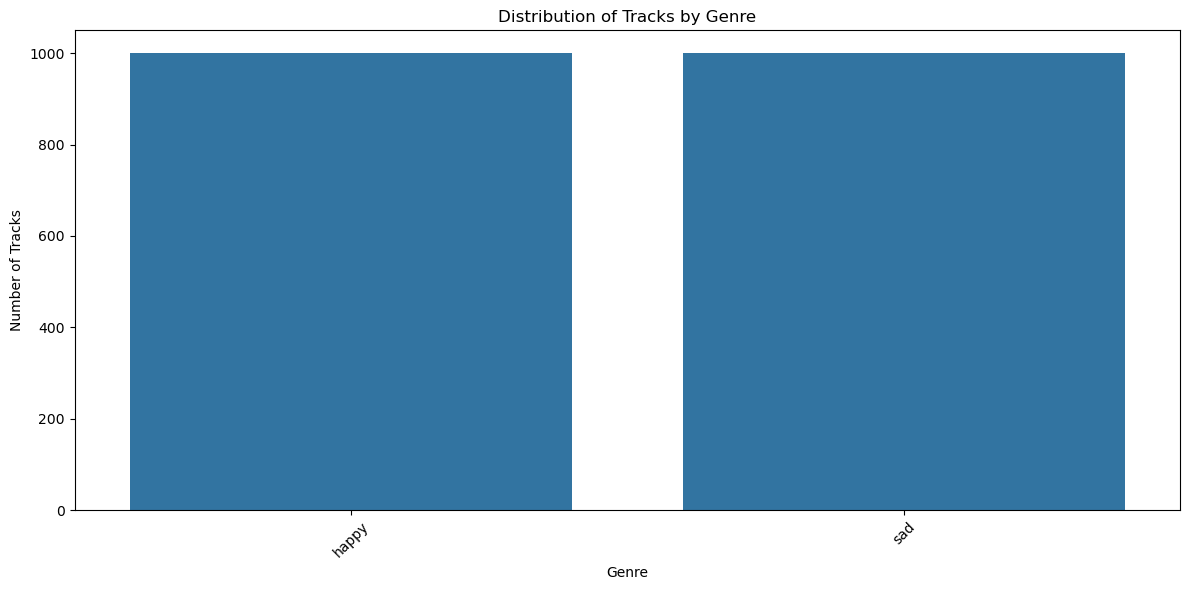

In [139]:
#Visualize Distribution of tracks by Genre

plt.figure(figsize=(12, 6))
sns.countplot(data=data_df, x='track_genre', order=data_df['track_genre'].value_counts().index)
plt.title('Distribution of Tracks by Genre')
plt.xticks(rotation=45)
plt.xlabel('Genre')
plt.ylabel('Number of Tracks')
plt.tight_layout()
plt.show()


In [140]:
#Encode Track genre, for example : 0 : Happy , 1: Sad 
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data_df['track_genre'] = le.fit_transform(data_df['track_genre'])

In [141]:
#Separate features and target variable
musical_features = [
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'time_signature']

X = data_df[musical_features]
y = data_df['track_genre']

#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 2 : Initialize the Classification Models

In [142]:
# Initialize models
decision_tree = DecisionTreeClassifier() #Initialise decision tree classifier
random_forest = RandomForestClassifier(random_state=42) #Initialise Random forest
naive_bayes = GaussianNB() #Initialise Guassian naive bayes classifier
knn = KNeighborsClassifier() #Initialise K nearest neighbor classifier

## Step 3 : Train the models

In [143]:
# here we train each model using X train and the traget y train because we are in supervised learning
decision_tree.fit(X_train, y_train) 
random_forest.fit(X_train, y_train)
naive_bayes.fit(X_train, y_train)
knn.fit(X_train, y_train)

KNeighborsClassifier()

## Step 4 : Understand the models 

### 1) Decision Tree 

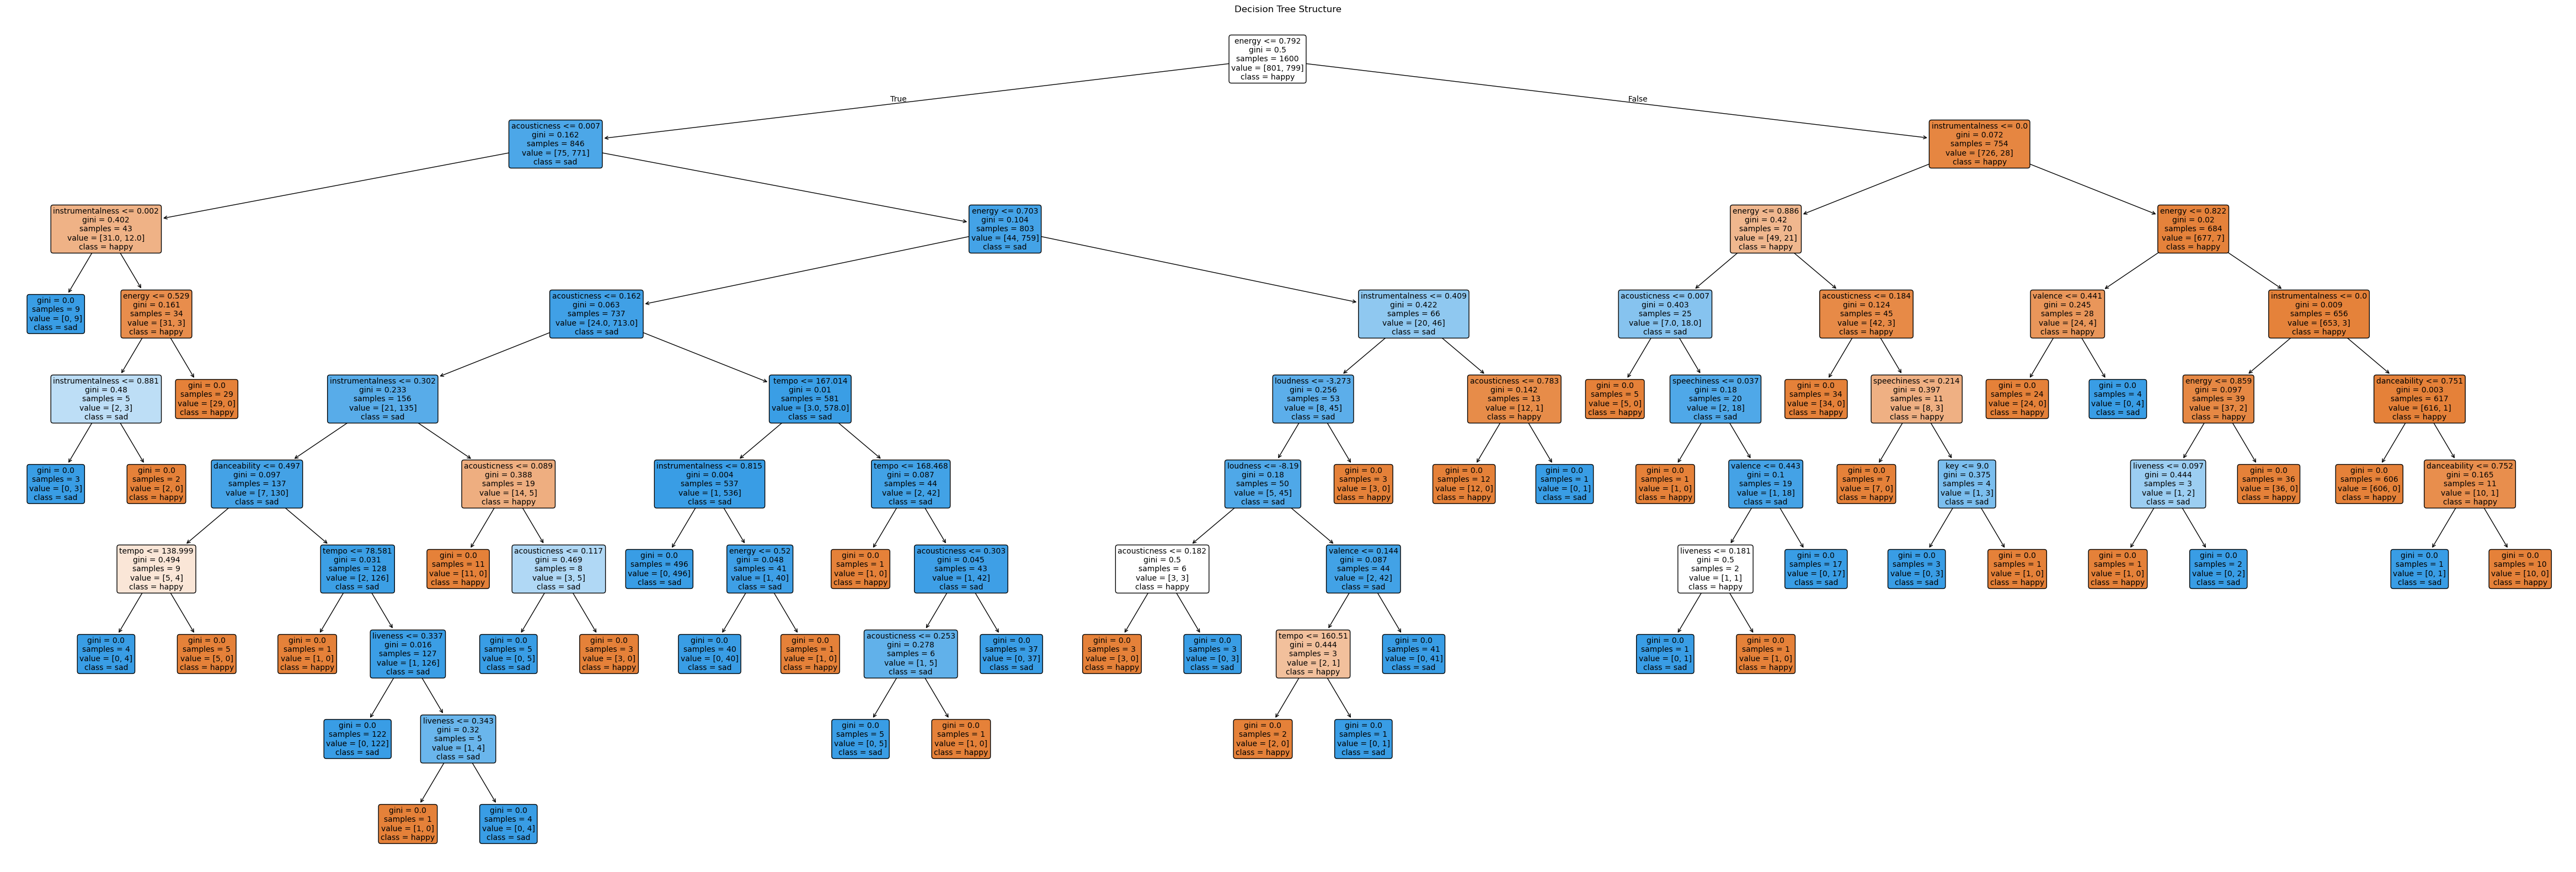

In [90]:
### Plot the Decision Tree Structure

plt.figure(figsize=(60, 20))  # Adjust the size as needed
plot_tree(decision_tree, 
          filled=True, 
          feature_names= list(X.columns), 
          class_names=['happy', 'sad'], 
          rounded=True, 
          fontsize=10)  # Adjust the font size as needed
plt.title('Decision Tree Structure')

# Save the plot as JPEG
plt.savefig('decision_tree.jpeg', format='jpeg', dpi=300)

# Show the plot (optional)
plt.show()


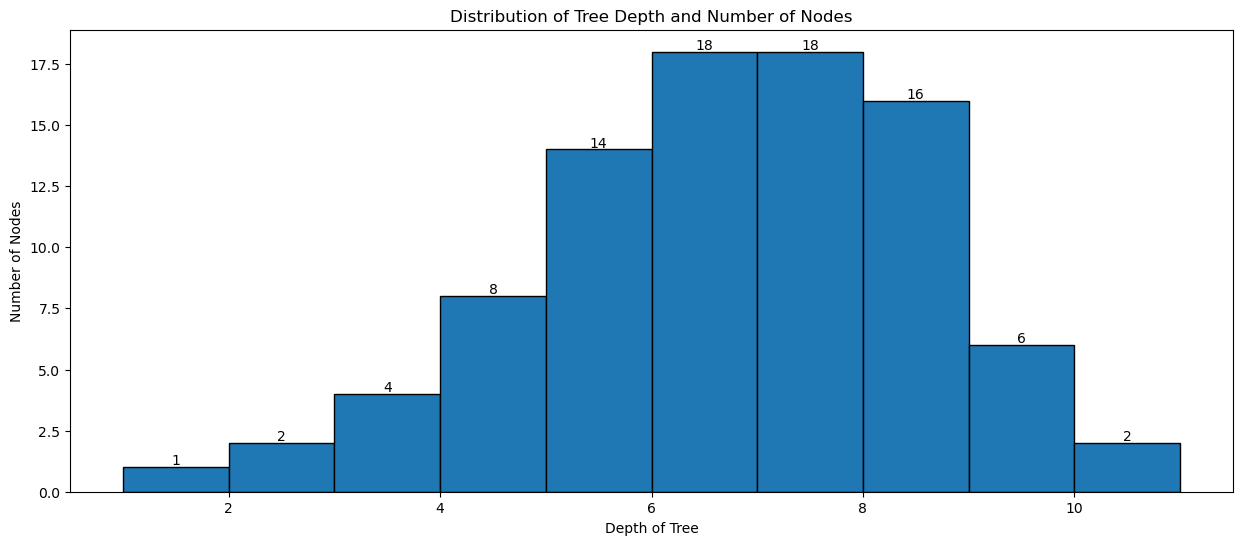

In [91]:
### Visualize Tree Depth and Number of Nodes


# Compute depths of the nodes
# Verify version 
depths = decision_tree.tree_.compute_node_depths()

# Create a histogram of the depths
plt.figure(figsize=(15, 6))
counts, bins, patches = plt.hist(depths, bins=np.arange(min(depths), max(depths) + 2), edgecolor='black')

# Annotate the histogram with the number of nodes
for count, bin in zip(counts, bins):
    plt.text(bin + 0.5, count+0.1, str(int(count)), ha='center')

plt.xlabel('Depth of Tree')
plt.ylabel('Number of Nodes')
plt.title('Distribution of Tree Depth and Number of Nodes')
plt.show()


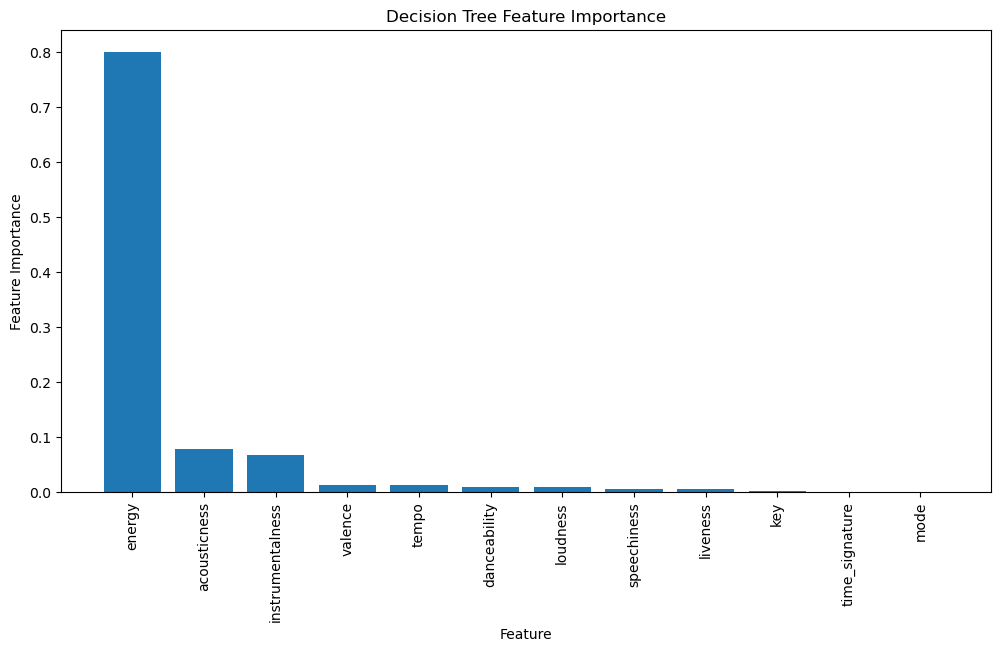

In [92]:
### Visualize the importance of each feature in the decision-making process of the tree

importances = decision_tree.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.xlabel('Feature')
plt.ylabel('Feature Importance')
plt.title('Decision Tree Feature Importance')
plt.show()


### 2) Random Forest 

In [77]:
random_forest.n_estimators

100

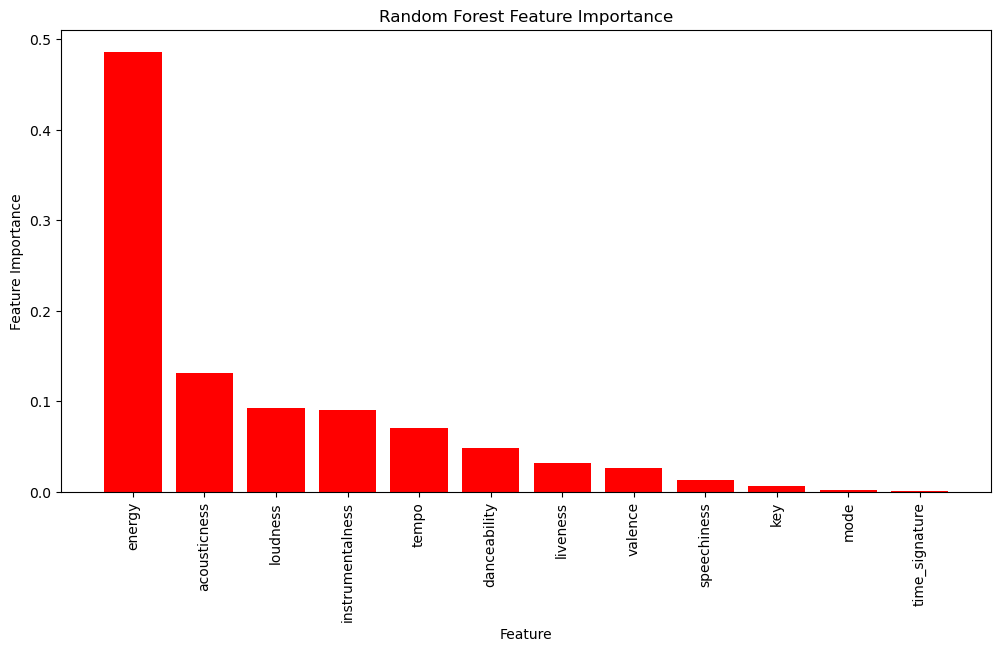

In [93]:
### 

# Compute feature importances
importances = random_forest.feature_importances_
indices = np.argsort(importances)[::-1]

# Create a bar plot
plt.figure(figsize=(12, 6))
plt.bar(range(X.shape[1]), importances[indices],color='r', align='center')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.xlabel('Feature')
plt.ylabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()


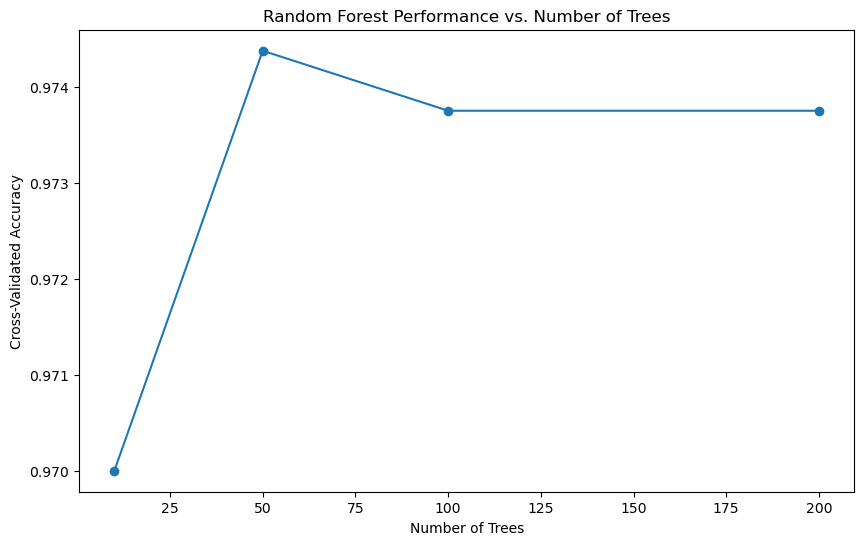

In [94]:
### 

from sklearn.model_selection import cross_val_score

n_trees = [10, 50, 100, 200]
scores = []

for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    score = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
    scores.append(score.mean())

plt.figure(figsize=(10, 6))
plt.plot(n_trees, scores, marker='o')
plt.title('Random Forest Performance vs. Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Cross-Validated Accuracy')
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


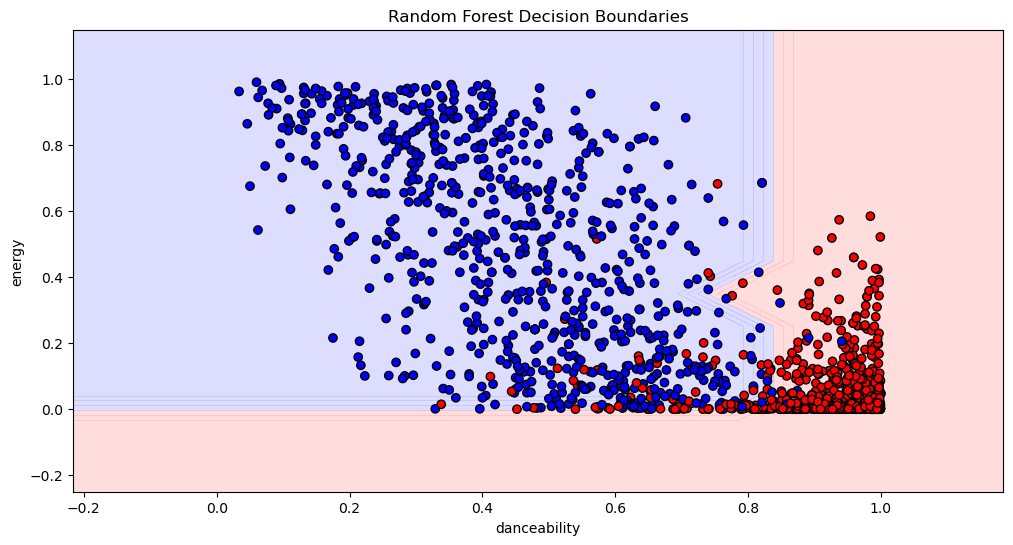

In [98]:
from matplotlib.colors import ListedColormap

# Assume X_train has only two features for this plot
#X_train_2d = X_train.iloc[:, :2]
X_train_2d = X_train[["energy", "acousticness"]]

# Train the Random Forest model on 2D data
random_forest_2d = RandomForestClassifier(random_state=42, n_estimators=100)
random_forest_2d.fit(X_train_2d, y_train)

# Create a mesh grid for plotting decision boundaries
x_min, x_max = X_train_2d.iloc[:, 0].min() - 0.25, X_train_2d.iloc[:, 0].max() + 0.25
y_min, y_max = X_train_2d.iloc[:, 1].min() - 0.25, X_train_2d.iloc[:, 1].max() + 0.25
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict class probabilities for each point in the mesh grid
Z = random_forest_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.figure(figsize=(12, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
plt.scatter(X_train_2d.iloc[:, 0], X_train_2d.iloc[:, 1], c=y_train, edgecolor='k', cmap=ListedColormap(['#FF0000', '#0000FF']))
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title('Random Forest Decision Boundaries')
plt.show()


### 3) Naive Bayes 

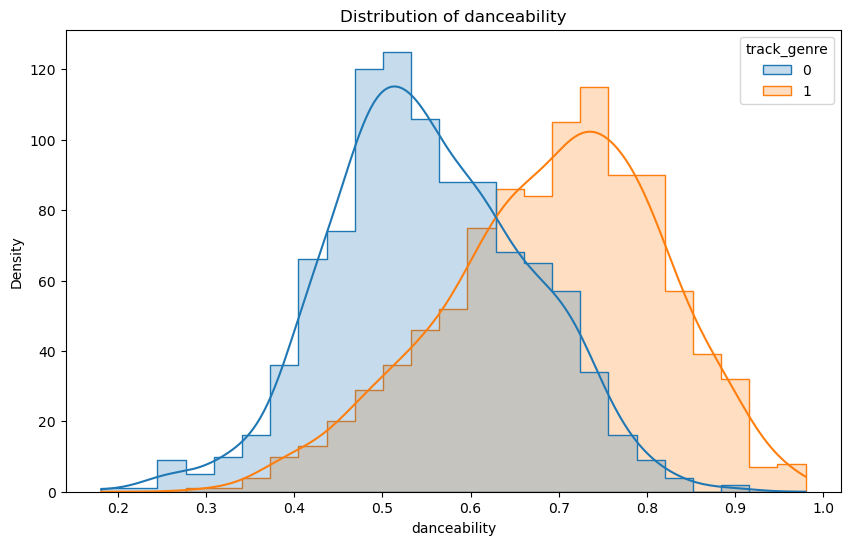

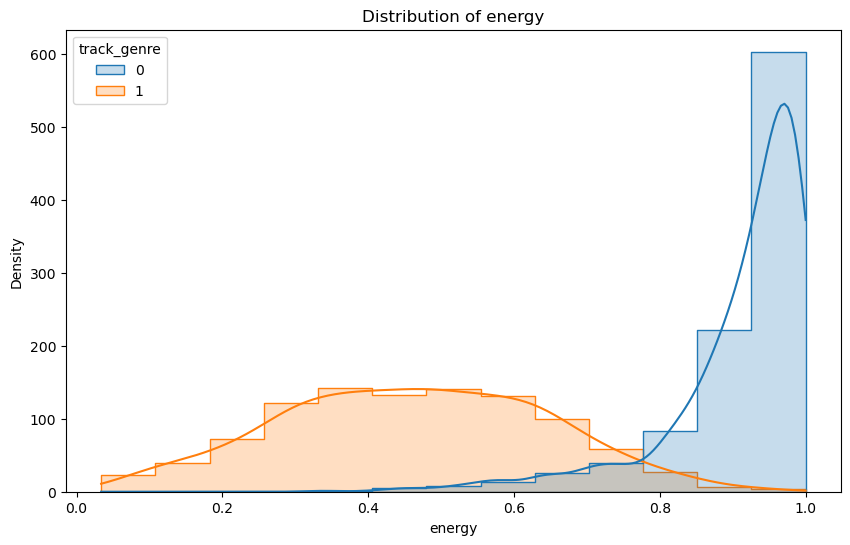

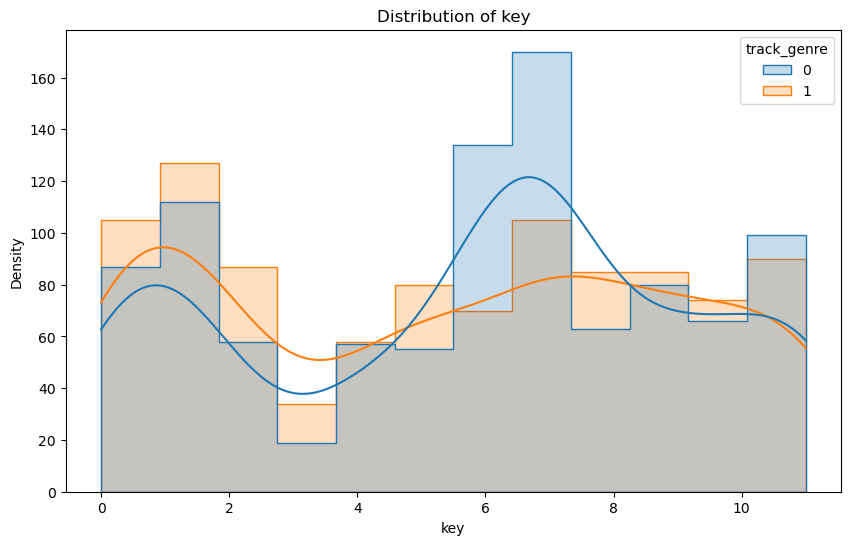

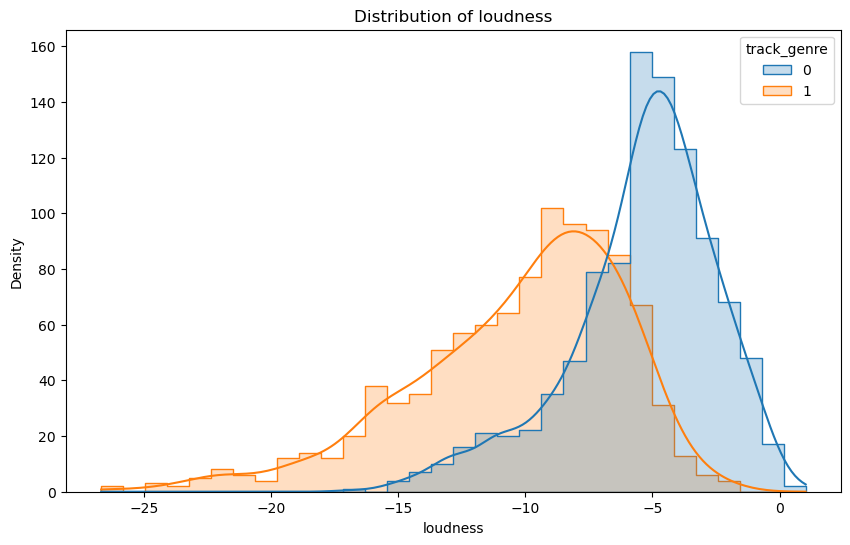

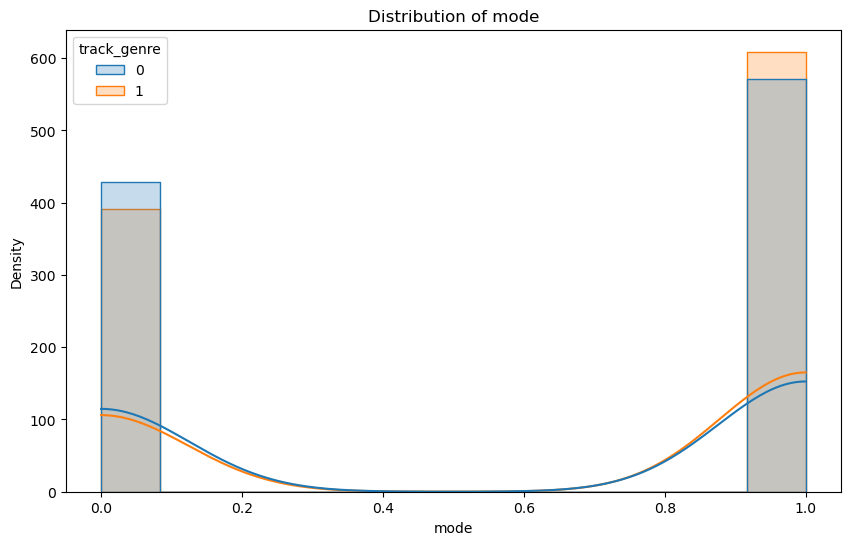

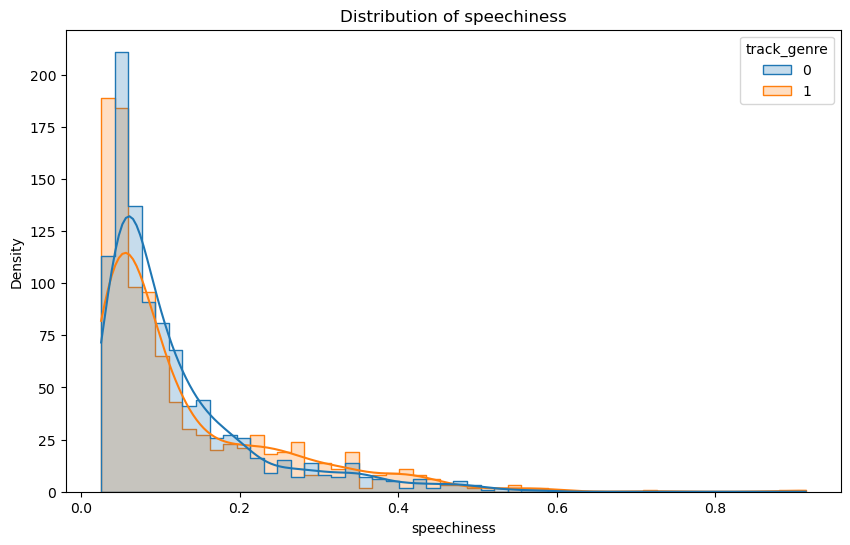

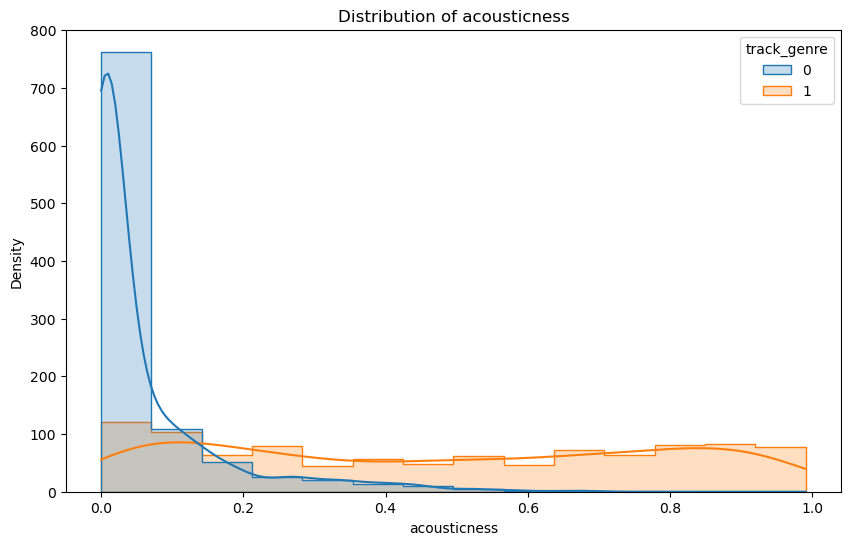

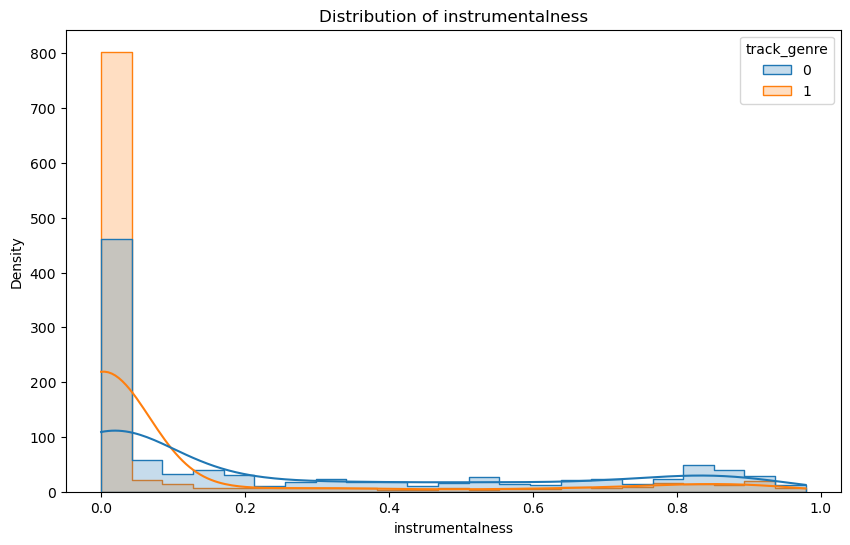

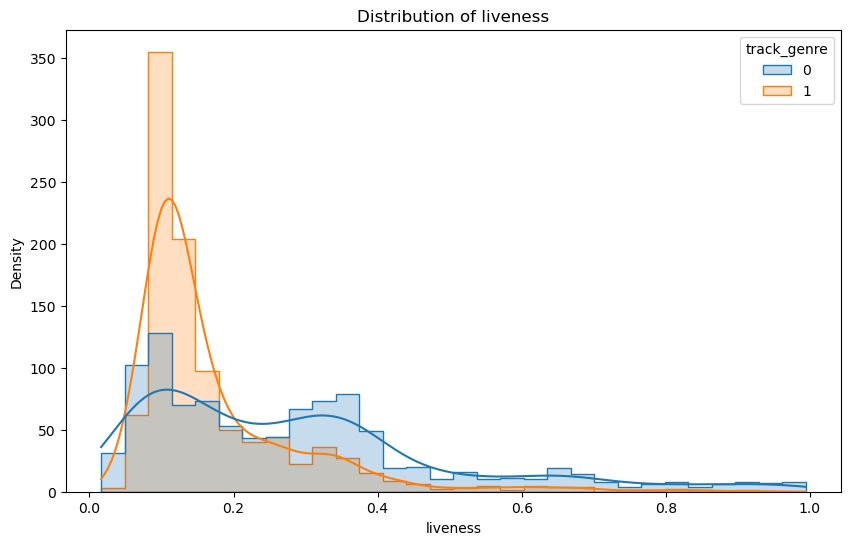

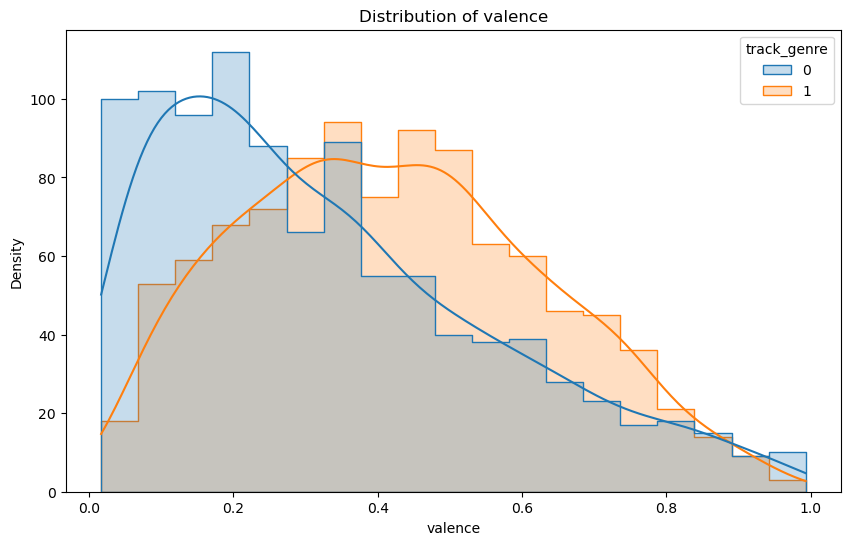

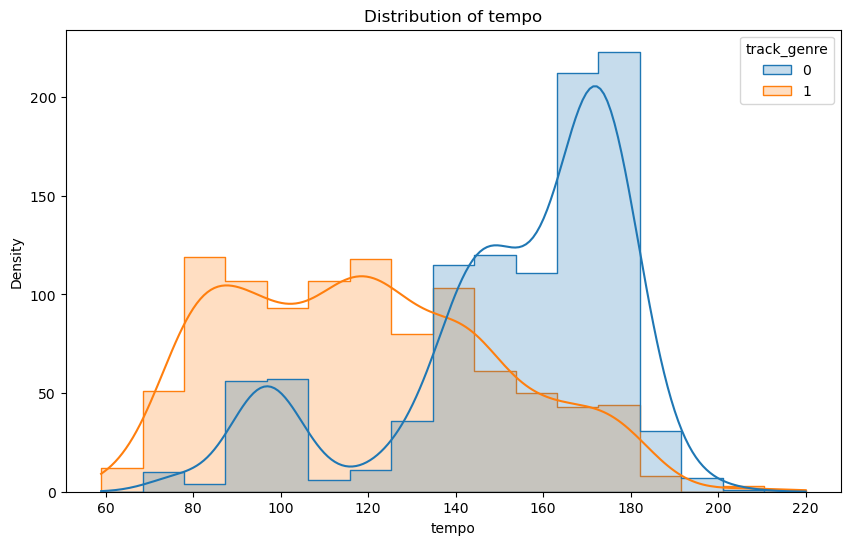

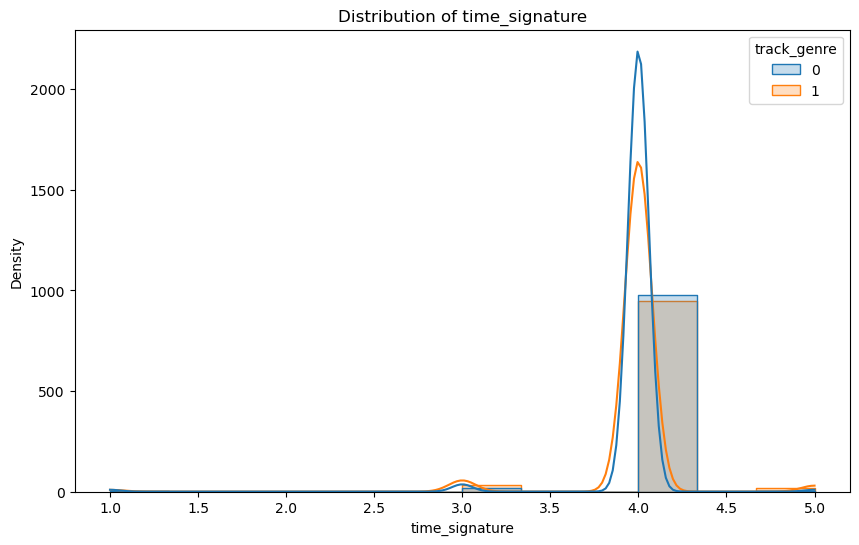

In [101]:
# Plot the Features Distributions 

features = X.columns  # All columns except the last one which is the target

# Plot feature distributions for each class
for feature in features:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=data_df, x=feature, hue='track_genre', kde=True, element='step')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.show()

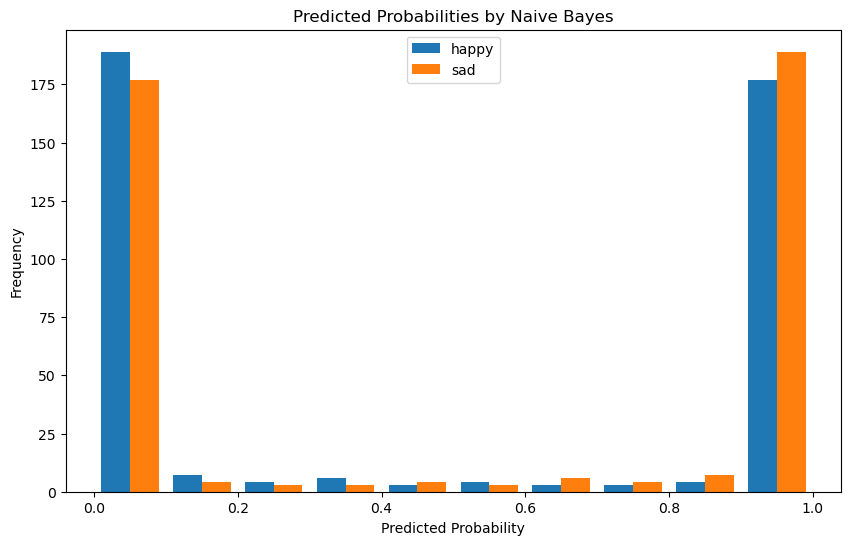

In [103]:
### Visualize the distribution of probabilities for each class

# Predict probabilities for the test set
y_prob = naive_bayes.predict_proba(X_test)

# Plot predicted probabilities for each class
plt.figure(figsize=(10, 6))
plt.hist(y_prob, bins=10, label=['happy', 'sad'])
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Predicted Probabilities by Naive Bayes')
plt.legend(loc= "upper center")
plt.show()


### 4) K-Nearest-Neighbors

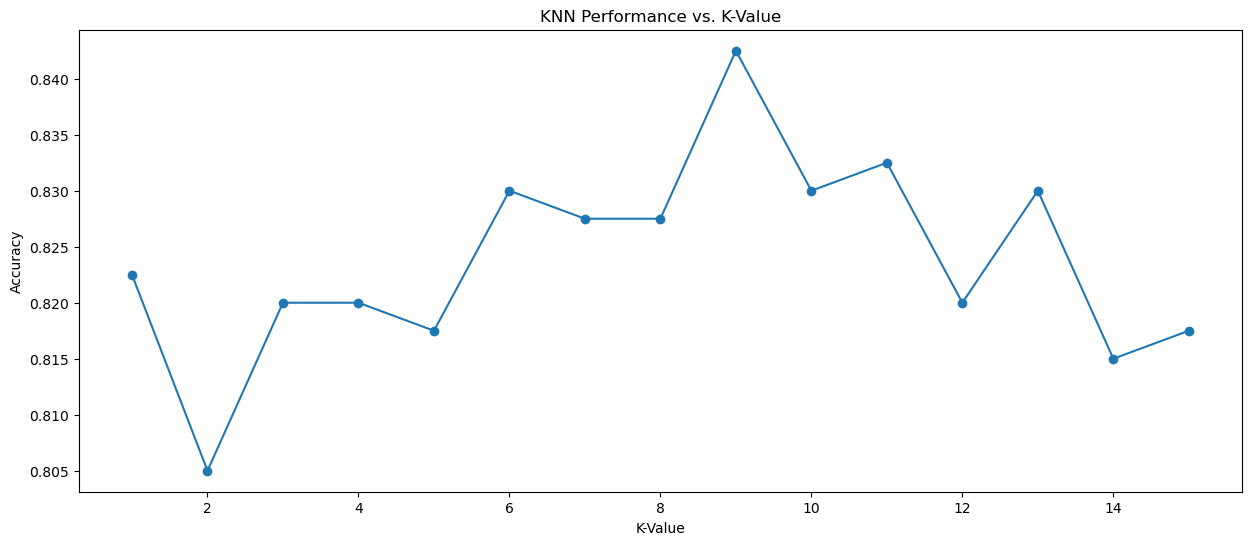

In [104]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

# Define range of K values to test
k_values = np.arange(1, 16)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    #score = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    #scores.append(score.mean())
    scores.append(knn.score(X_test, y_test))

# Plot the accuracy
plt.figure(figsize=(15, 6))
plt.plot(k_values, scores, marker='o')
plt.title('KNN Performance vs. K-Value')
plt.xlabel('K-Value')
plt.ylabel('Accuracy')
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


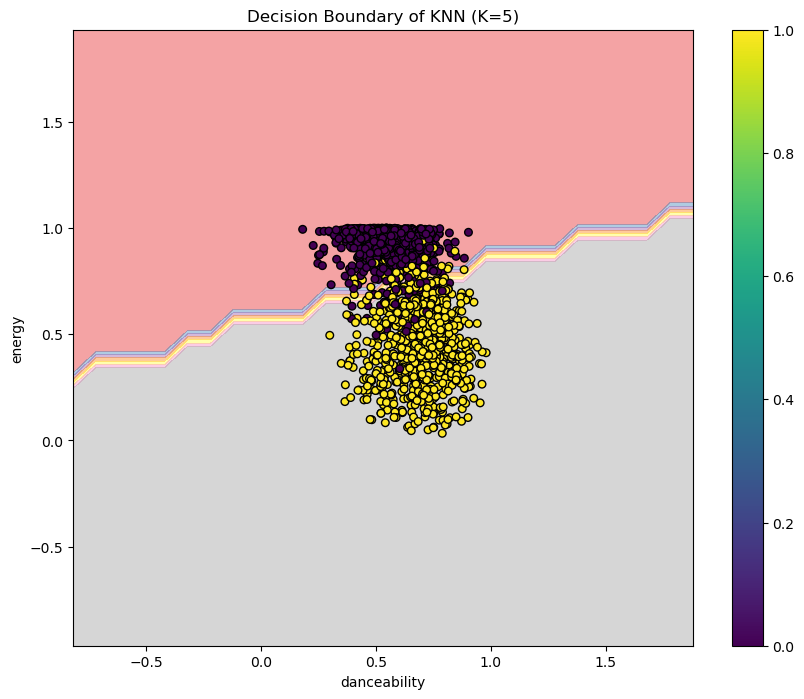

In [105]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

# Assume X_train has only two features for this plot
X_train_2d = X_train.iloc[:, :2]

# Train the KNN classifier on 2D data
knn = KNeighborsClassifier(n_neighbors=11)
knn.fit(X_train_2d, y_train)

# Create a mesh grid for plotting decision boundaries
x_min, x_max = X_train_2d.iloc[:, 0].min() - 1, X_train_2d.iloc[:, 0].max() + 1
y_min, y_max = X_train_2d.iloc[:, 1].min() - 1, X_train_2d.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Predict class probabilities for each point in the mesh grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.Set1)

plt.scatter(X_train_2d.iloc[:, 0], X_train_2d.iloc[:, 1], c=y_train, s=30, edgecolor='k') # add cmap=plt.cm.Set1 to see another palette
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title('Decision Boundary of KNN (K=5)')
plt.colorbar()
plt.show()

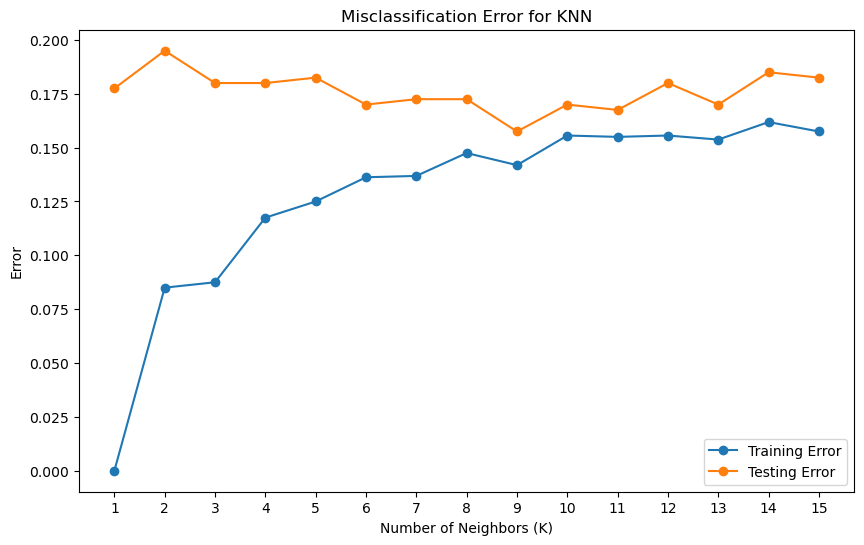

In [106]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

# Define range of K values to test
param_range = np.arange(1, 16)

# Calculate error on training and test set using cross-validation
train_errors, test_errors = [], []
for k in param_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_errors.append(1 - knn.score(X_train, y_train))
    test_errors.append(1 - knn.score(X_test, y_test))

# Plot misclassification error
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_errors, label='Training Error', marker='o')
plt.plot(param_range, test_errors, label='Testing Error', marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Error')
plt.title('Misclassification Error for KNN')
plt.xticks(param_range)
plt.legend()
plt.show()


## Step 5 : Make Predictions

In [108]:
y_pred_decision_tree = decision_tree.predict(X_test)
y_pred_random_forest = random_forest.predict(X_test)
y_pred_naive_bayes = naive_bayes.predict(X_test)
y_pred_knn = knn.predict(X_test)

## Step 6 : Evaluate Models

In [109]:
# Function to calculate results and return as a dictionary
def calculate_results(y_test, y_pred, model_name):
    correct_predictions = np.sum(y_test == y_pred)
    incorrect_predictions = len(y_test) - correct_predictions
    percentage_correct = (correct_predictions / len(y_test)) * 100
    percentage_incorrect = (incorrect_predictions / len(y_test)) * 100
    
    results = {
        'Model': model_name,
        'Correct Predictions': correct_predictions,
        'Incorrect Predictions': incorrect_predictions,
        'Percentage Correct': percentage_correct,
        'Percentage Incorrect': percentage_incorrect
    }
    
    return results

# Collect results for each model
results_list = []
results_list.append(calculate_results(y_test, y_pred_decision_tree, 'Decision Tree'))
results_list.append(calculate_results(y_test, y_pred_random_forest, 'Random Forest'))
results_list.append(calculate_results(y_test, y_pred_naive_bayes, 'Naive Bayes'))
results_list.append(calculate_results(y_test, y_pred_knn, 'KNN'))

# Convert list of dictionaries to DataFrame
results_df = pd.DataFrame(results_list)

# Display the DataFrame
results_df

,Model,Correct Predictions,Incorrect Predictions,Percentage Correct,Percentage Incorrect
0,Decision Tree,375,25,93.75,6.25
1,Random Forest,386,14,96.50,3.50
2,Naive Bayes,378,22,94.50,5.50
3,KNN,327,73,81.75,18.25


#### Evalluating using Classification Metrics ###

In [127]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Evaluation Metrics for Decision Tree
accuracy = accuracy_score(y_test, y_pred_decision_tree)
precision = precision_score(y_test, y_pred_decision_tree)
# Compute recall
recall = recall_score(y_test, y_pred_decision_tree)
# Compute F1 score
f1 = f1_score(y_test, y_pred_decision_tree)

# Print evaluation metrics
print("Decision Tree Classifier Performance:")
print(f"Accuracy: {accuracy}")
print(f"precision: {precision}")
print(f"recall: {recall}")
print(f"f1_score: {f1}")

print ("---------------------------------------------")
# Evaluation Metrics for Random Forest

accuracy = accuracy_score(y_test, y_pred_random_forest)
precision = precision_score(y_test, y_pred_random_forest)
# Compute recall
recall = recall_score(y_test, y_pred_random_forest)
# Compute F1 score
f1 = f1_score(y_test, y_pred_random_forest)

# Print evaluation metrics
print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy}")
print(f"precision: {precision}")
print(f"recall: {recall}")
print(f"f1_score: {f1}")

print ("---------------------------------------------")
# Evaluation Metrics for Naive Bayes

accuracy = accuracy_score(y_test, y_pred_naive_bayes)
precision = precision_score(y_test, y_pred_naive_bayes)
# Compute recall
recall = recall_score(y_test, y_pred_naive_bayes)
# Compute F1 score
f1 = f1_score(y_test, y_pred_naive_bayes)

# Print evaluation metrics
print("Naive bayes Classifier Performance:")

print(f"Accuracy: {accuracy}")
print(f"precision: {precision}")
print(f"recall: {recall}")
print(f"f1_score: {f1}")

print ("---------------------------------------------")
# Evaluation Metrics for KNN
accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn)
# Compute recall
recall = recall_score(y_test, y_pred_knn)
# Compute F1 score
f1 = f1_score(y_test, y_pred_knn)

# Print evaluation metrics
print("KNN Classifier Performance:")

print(f"Accuracy: {accuracy}")
print(f"precision: {precision}")
print(f"recall: {recall}")
print(f"f1_score: {f1}")

Decision Tree Classifier Performance:
Accuracy: 0.9375
precision: 0.94
recall: 0.9353233830845771
f1_score: 0.9376558603491272
---------------------------------------------
Random Forest Classifier Performance:
Accuracy: 0.965
precision: 0.9473684210526315
recall: 0.9850746268656716
f1_score: 0.9658536585365853
---------------------------------------------
Naive bayes Classifier Performance:
Accuracy: 0.945
precision: 0.9282296650717703
recall: 0.9651741293532339
f1_score: 0.9463414634146341
---------------------------------------------
KNN Classifier Performance:
Accuracy: 0.8175
precision: 0.8516483516483516
recall: 0.7711442786069652
f1_score: 0.8093994778067886


#### Export the Predictions

In [128]:
# Create a DataFrame for each algorithm
# This part to export the results for the next lab  Stay tuned ....
#we just created a data frame for every algorithm output 
import pandas as pd
df_decision_tree = pd.DataFrame({'Actual Values': y_test, 'Predicted Values (Decision Tree)': y_pred_decision_tree})
df_random_forest = pd.DataFrame({'Actual Values': y_test, 'Predicted Values (Random Forest)': y_pred_random_forest})
df_naive_bayes = pd.DataFrame({'Actual Values': y_test, 'Predicted Values (Naive Bayes)': y_pred_naive_bayes})
df_knn = pd.DataFrame({'Actual Values': y_test, 'Predicted Values (KNN)': y_pred_knn})

# and then created an Excel writer object
with pd.ExcelWriter('predicted_vs_actual.xlsx') as writer:
    # Write each DataFrame to a separate sheet
    df_decision_tree.to_excel(writer, sheet_name='Decision Tree', index=False)
    df_random_forest.to_excel(writer, sheet_name='Random Forest', index=False)
    df_naive_bayes.to_excel(writer, sheet_name='Naive Bayes', index=False)
    df_knn.to_excel(writer, sheet_name='KNN', index=False)
